In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
X, y = make_classification(
    n_samples=2000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_classes=2,
    weights=[0.7, 0.3],
    random_state=42
)
print("Dataset Shape:", X.shape)
print("Class Distribution:", np.bincount(y))
df = pd.DataFrame(X)
df["Target"] = y
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (2000, 10)
Class Distribution: [1396  604]

First 5 rows:
          0         1         2         3         4         5         6  \
0 -0.527985  2.502247  0.695293 -1.795216 -1.116564 -1.533083 -2.463545   
1 -0.969457 -0.027843  0.491814 -0.904605  0.095751  1.047343 -0.838283   
2 -0.233425 -1.991787 -0.457817 -0.407070 -2.221362 -2.598014  0.857989   
3 -1.746842  1.005994 -1.276618 -2.529162 -1.537575 -2.303886 -0.133311   
4 -1.297131 -1.451861  1.791782 -0.512722 -0.622481 -1.066218 -1.250867   

          7         8         9  Target  
0  1.197423 -1.900653  3.487929       0  
1 -0.857172 -0.848319  0.039613       0  
2 -0.579129 -1.251154  0.165376       0  
3 -0.748383  0.509019  2.254463       0  
4 -0.000132 -0.928541  0.423256       0  


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (1500, 10)
Test set size: (500, 10)


In [10]:
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)

print("Model Parameters:")
print(model.get_params())

Model Parameters:
{'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 10, 'min_samples_split': 20, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


In [11]:

model.fit(X_train, y_train)

print("Model training completed!")
print(f"Tree depth: {model.get_depth()}")
print(f"Number of leaves: {model.get_n_leaves()}")

Model training completed!
Tree depth: 5
Number of leaves: 23


In [13]:
print("First 10 Predictions:", y_pred[:10])
print("First 10 Probabilities:", y_prob[:10])

First 10 Predictions: [1 1 0 0 1 0 1 1 0 0]
First 10 Probabilities: [[0.12247223 0.87752777]
 [0.42859187 0.57140813]
 [1.         0.        ]
 [0.73784673 0.26215327]
 [0.1115917  0.8884083 ]
 [0.73784673 0.26215327]
 [0.42859187 0.57140813]
 [0.         1.        ]
 [1.         0.        ]
 [0.95477    0.04523   ]]


In [15]:
print("\n" + "="*55)
print("     BINARY CLASSIFICATION (Entropy) - RESULTS")
print("="*55)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))


     BINARY CLASSIFICATION (Entropy) - RESULTS

Accuracy: 0.8600

Confusion Matrix:
[[312  57]
 [ 13 118]]

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.96      0.85      0.90       369
     Class 1       0.67      0.90      0.77       131

    accuracy                           0.86       500
   macro avg       0.82      0.87      0.84       500
weighted avg       0.89      0.86      0.87       500




Top Feature Importances (Entropy-based):
     Feature  Importance
6  Feature_6    0.435048
4  Feature_4    0.287497
5  Feature_5    0.106355
0  Feature_0    0.064931
9  Feature_9    0.043375
1  Feature_1    0.030321
8  Feature_8    0.026723
2  Feature_2    0.005751
3  Feature_3    0.000000
7  Feature_7    0.000000


C:\Users\aceec\AppData\Local\Temp\ipykernel_1600\2371017358.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='viridis')


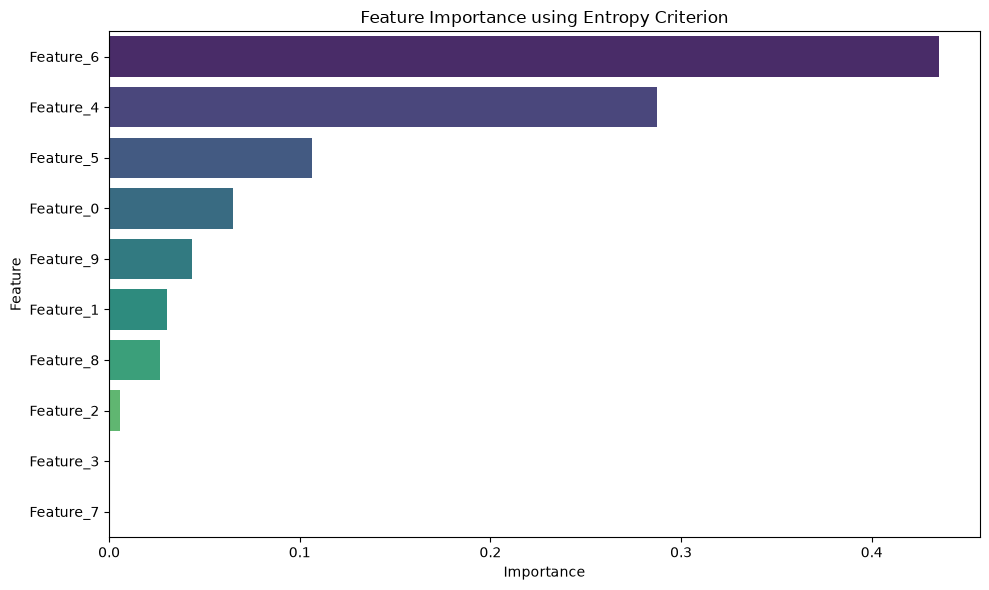

In [16]:
feature_names = [f'Feature_{i}' for i in range(X.shape[1])]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop Feature Importances (Entropy-based):")
print(importance_df.head(10))

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance using Entropy Criterion')
plt.tight_layout()
plt.show()

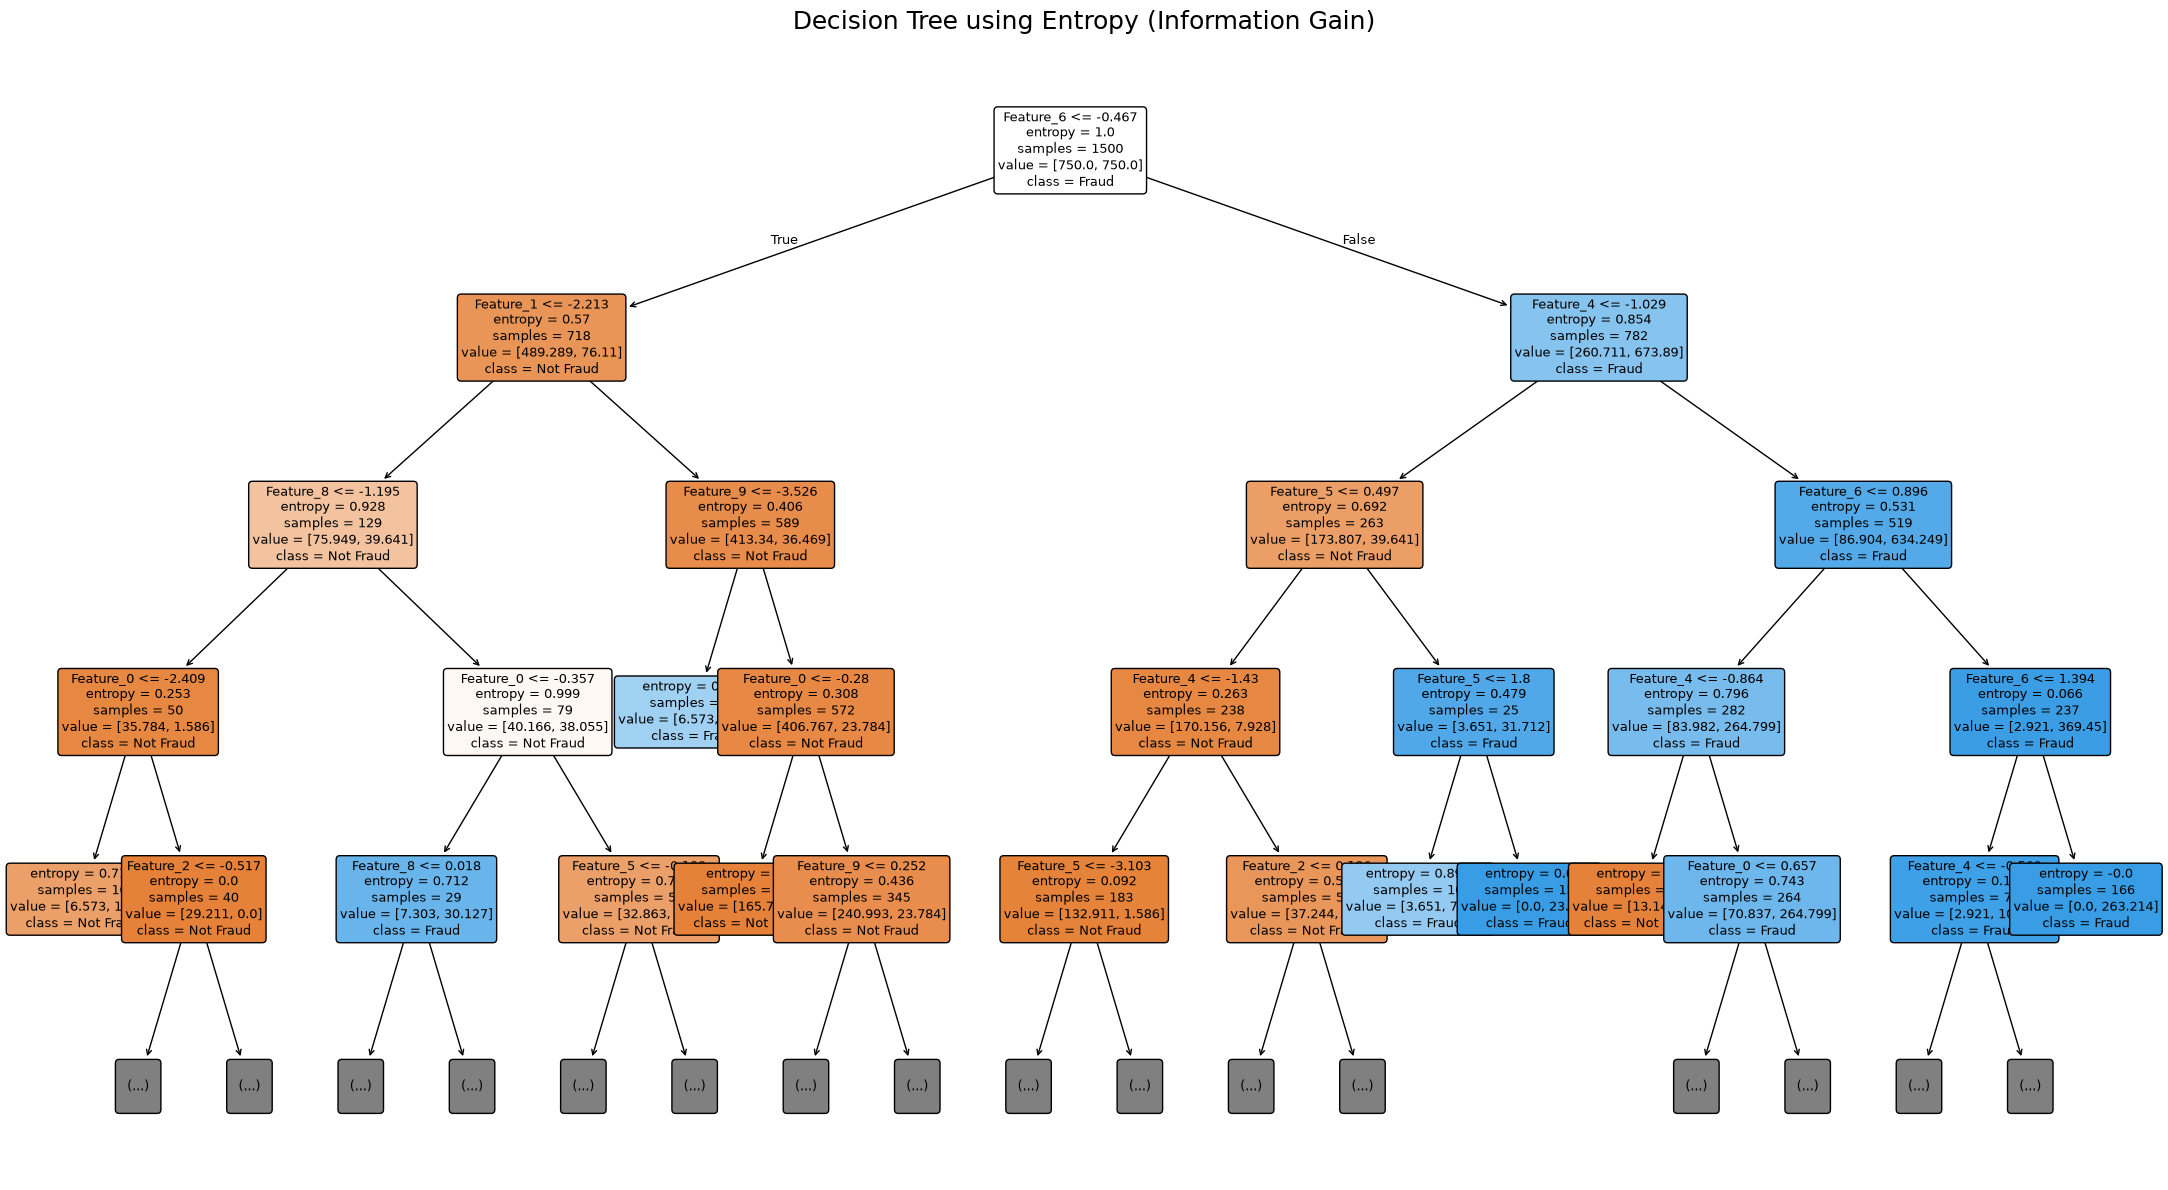

In [17]:
plt.figure(figsize=(22, 12))

plot_tree(
    model,
    feature_names=[f'Feature_{i}' for i in range(X.shape[1])],
    class_names=['Not Fraud', 'Fraud'],   # Change according to your problem
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=4                          # You can increase this if tree is small
)

plt.title("Decision Tree using Entropy (Information Gain)", fontsize=18, pad=20)
plt.tight_layout()
plt.show()